In [1]:
!pip install gdown

In [ ]:
!mkdir -p local/data && cd local/data

# Download
!gdown 1zHmnVaItcYJAWat3Yti1W_5Nfux194WQ -O local/data/  # split
!gdown 1K8Zf0ju_xI5lnx3NTDLJpVTs59wmGPI6 -O local/data/  # ontology
!gdown 16URBUQn_VOGvUqfms-0I8HHKMtjPHsu5 -O local/data/  # labels
!gdown 1F3Leu0H_m6aPVpZITragfreO_SGtL2yV -O local/data/  # images

Downloading...
From: https://drive.google.com/uc?id=1zHmnVaItcYJAWat3Yti1W_5Nfux194WQ
To: /home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/examples/local/data/Rellis_3D_image_split.zip
100%|██████████████████████████████████████| 44.7k/44.7k [00:00<00:00, 5.28MB/s]
Downloading...
From: https://drive.google.com/uc?id=1K8Zf0ju_xI5lnx3NTDLJpVTs59wmGPI6
To: /home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/examples/local/data/Rellis_3D_ontology.zip
100%|██████████████████████████████████████| 18.2k/18.2k [00:00<00:00, 2.63MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=16URBUQn_VOGvUqfms-0I8HHKMtjPHsu5
From (redirected): https://drive.google.com/uc?id=16URBUQn_VOGvUqfms-0I8HHKMtjPHsu5&confirm=t&uuid=c3dd189d-5497-42f2-81e1-ce58dd141e19
To: /home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/examples/local/data/Rellis_3D_pylon_camera_node_label_id.zip
  5%|██                                    | 5.24M/98.9M [00:01<00:22, 4.20M

In [1]:
# Download
!gdown 15Py3AKyGzWNX4M3OJKlQQsnH6IehkoEd -O local/data/image_segmentation_model.pth            # model
!gdown 17eJ6aei6yBAbK1aA4mhTeMdXYycorqcT -O local/data/image_segmentation_model_cfg.json       # configuration
!gdown 1spXt5_ISG1ZaHHO2DTtCSqgkohnhwuzt -O local/data/image_segmentation_model_ontology.json  # ontology

Downloading...
From (original): https://drive.google.com/uc?id=15Py3AKyGzWNX4M3OJKlQQsnH6IehkoEd
From (redirected): https://drive.google.com/uc?id=15Py3AKyGzWNX4M3OJKlQQsnH6IehkoEd&confirm=t&uuid=d32b2a6e-93ce-4132-a555-288bb1bd26d6
To: /home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/examples/local/data/image_segmentation_model.pth
100%|████████████████████████████████████████| 159M/159M [00:31<00:00, 5.07MB/s]
Downloading...
From: https://drive.google.com/uc?id=17eJ6aei6yBAbK1aA4mhTeMdXYycorqcT
To: /home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/examples/local/data/image_segmentation_model_cfg.json
100%|██████████████████████████████████████████| 288/288 [00:00<00:00, 2.75MB/s]
Downloading...
From: https://drive.google.com/uc?id=1spXt5_ISG1ZaHHO2DTtCSqgkohnhwuzt
To: /home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/examples/local/data/image_segmentation_model_ontology.json
100%|██████████████████████████████████████| 2.31k/2.31k [00:00<

In [4]:
from perceptionmetrics.models.torch_segmentation import TorchImageSegmentationModel

model = TorchImageSegmentationModel(
    model="local/data/image_segmentation_model.pth",
    model_cfg="local/data/image_segmentation_model_cfg.json",
    ontology_fname="local/data/image_segmentation_model_ontology.json",
)

In [5]:
## NuImages Segmentation Dataset and Model

import json
from pathlib import Path

from perceptionmetrics.models.torch_segmentation import TorchImageSegmentationModel
from perceptionmetrics.datasets.nuimages import NuImagesSegmentationDataset

dataset = NuImagesSegmentationDataset(
    dataset_dir="local/data/nuimages-v1.0-mini", version="v1.0-mini", split="train"
)

# Build compact ontology (contiguous idx: 0..N-1) to avoid sparse-index issues (e.g., idx 31).
sorted_items = sorted(dataset.ontology.items(), key=lambda x: x[1]["idx"] )
compact_ontology = {
    class_name: {
        "idx": new_idx,
        "rgb": class_meta.get("rgb", [0, 0, 0]),
    }
    for new_idx, (class_name, class_meta) in enumerate(sorted_items)
}

ontology_path = Path("local/data/nuimages_segmentation_ontology_compact.json")
ontology_path.parent.mkdir(parents=True, exist_ok=True)
with open(ontology_path, "w") as f:
    json.dump(compact_ontology, f, indent=2)

max_idx = max(v["idx"] for v in compact_ontology.values())
print(
    f"Saved compact ontology to {ontology_path} with {len(compact_ontology)} classes (max idx={max_idx})"
 )

model = TorchImageSegmentationModel(
    model="local/data/image_segmentation_model.pth",
    model_cfg="local/data/image_segmentation_model_cfg.json",
    ontology_fname=str(ontology_path),
)

Built nuImages segmentation dataset with 50 samples and 26 classes.
Saved compact ontology to local/data/nuimages_segmentation_ontology_compact.json with 26 classes (max idx=25)


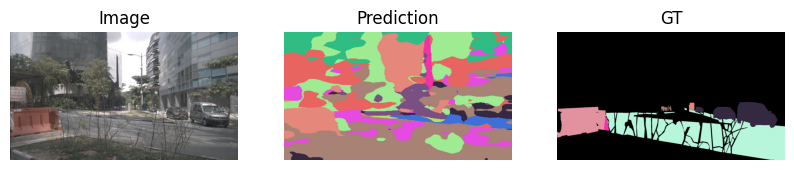

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

from perceptionmetrics.utils import conversion as uc

image_fname = dataset.dataset["image"].iloc[0]
image = Image.open(image_fname)

label_fname = dataset.dataset["label"].iloc[0]
label = Image.open(label_fname)
label = uc.label_to_rgb(label, dataset.ontology)

pred = model.predict(image)
pred = uc.label_to_rgb(pred, model.ontology)
pred = pred.resize(label.size)

plt.figure(figsize=(10, 10))
plt.subplot(131), plt.title("Image"), plt.imshow(np.array(image)), plt.axis("off")
plt.subplot(132), plt.title("Prediction"), plt.imshow(np.array(pred)), plt.axis("off")
plt.subplot(133), plt.title("GT"), plt.imshow(np.array(label)), plt.axis("off")
plt.show()

In [10]:
# Inspect overlap first
model_classes = set(model.ontology.keys())
dataset_classes = set(dataset.ontology.keys())
print("Model classes:", len(model_classes))
print("Dataset classes:", len(dataset_classes))
print(
    "Overlap:",
    len(model_classes & dataset_classes),
    sorted(model_classes & dataset_classes)[:20],
)

# Build a safe translation map
# old_ontology = dataset.ontology, new_ontology = model.ontology
# dataset ontology -> model ontology
fallback = list(model.ontology.keys())[0]
ontology_translation = {
    class_name: (class_name if class_name in model.ontology else fallback)
    for class_name in dataset.ontology.keys()
}

# TorchImageSegmentationModel.eval expects a JSON filename, not a Python dict.
translation_path = Path("local/data/nuimages_to_model_ontology_translation.json")
translation_path.parent.mkdir(parents=True, exist_ok=True)
with open(translation_path, "w", encoding="utf-8") as f:
    json.dump(ontology_translation, f, indent=2)

results = model.eval(
    dataset,
    split="train",
    ontology_translation=str(translation_path),
)
display(results)

Model classes: 26
Dataset classes: 26
Overlap: 26 ['animal', 'background', 'flat.driveable_surface', 'human.pedestrian.adult', 'human.pedestrian.child', 'human.pedestrian.construction_worker', 'human.pedestrian.personal_mobility', 'human.pedestrian.police_officer', 'human.pedestrian.stroller', 'human.pedestrian.wheelchair', 'movable_object.barrier', 'movable_object.debris', 'movable_object.pushable_pullable', 'movable_object.trafficcone', 'static_object.bicycle_rack', 'vehicle.bicycle', 'vehicle.bus.bendy', 'vehicle.bus.rigid', 'vehicle.car', 'vehicle.construction']


100%|██████████| 50/50 [00:01<00:00, 49.51it/s]
/home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:147: RuntimeWarning: invalid value encountered in divide
  return np.where(denominator > 0, tp / denominator, np.nan)
/home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:164: RuntimeWarning: invalid value encountered in divide
  return np.where(denominator > 0, tp / denominator, np.nan)
/home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:203: RuntimeWarning: invalid value encountered in divide
  denominator > 0, 2 * (precision * recall) / denominator, np.nan
/home/tejass/Downloads/JDE_Robotics/Tejas_fork/PerceptionMetrics/perceptionmetrics/utils/segmentation_metrics.py:222: RuntimeWarning: invalid value encountered in divide
  return np.where(union > 0, tp / union, np.nan)
/home/tejass/Downloads/JDE_Robotics

,background,animal,human.pedestrian.adult,human.pedestrian.child,human.pedestrian.construction_worker,human.pedestrian.personal_mobility,human.pedestrian.police_officer,human.pedestrian.stroller,human.pedestrian.wheelchair,movable_object.barrier,...,vehicle.construction,vehicle.emergency.ambulance,vehicle.emergency.police,vehicle.motorcycle,vehicle.trailer,vehicle.truck,flat.driveable_surface,vehicle.ego,macro,micro
tp,0.000000e+00,0.0,2.307000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.150000e+02,...,1.060000e+02,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN
fp,0.000000e+00,0.0,1.324092e+06,1.144981e+06,0.000000e+00,5.514000e+03,5.146350e+05,4.000000e+00,2.264000e+03,2.997000e+03,...,5.057800e+04,1.052410e+05,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,NaN,NaN
fn,3.720936e+06,0.0,1.771800e+04,0.000000e+00,6.570000e+02,4.960000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.872600e+04,...,4.996600e+04,0.000000e+00,0.0,9.621000e+03,8.363000e+03,3.112100e+04,1.003976e+06,9.863800e+04,NaN,NaN
tn,1.399064e+06,5120000.0,3.775883e+06,3.975019e+06,5.119343e+06,5.113990e+06,4.605365e+06,5.119996e+06,5.117736e+06,5.088162e+06,...,5.019350e+06,5.014759e+06,5120000.0,5.110379e+06,5.111637e+06,5.088879e+06,4.116024e+06,5.021362e+06,NaN,NaN
precision,NaN,NaN,1.739296e-03,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.695373e-02,...,2.091390e-03,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,0.006657,0.002269
recall,0.000000e+00,NaN,1.152060e-01,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,3.987379e-03,...,2.116952e-03,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.046640,0.002269
accuracy,2.732547e-01,1.0,7.379277e-01,7.763709e-01,9.998717e-01,9.988262e-01,8.994854e-01,9.999992e-01,9.995578e-01,9.938041e-01,...,9.803625e-01,9.794451e-01,1.0,9.981209e-01,9.983666e-01,9.939217e-01,8.039109e-01,9.807348e-01,0.923251,0.923251
f1_score,NaN,NaN,3.426855e-03,NaN,NaN,NaN,NaN,NaN,NaN,7.198072e-03,...,2.104093e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009924,0.002269
iou,0.000000e+00,NaN,1.716368e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.612036e-03,...,1.053154e-03,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.001463,0.001136
dice_score,0.000000e+00,NaN,3.426855e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.198072e-03,...,2.104093e-03,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.002895,0.002269
